# Data Exploration — PS Ep6 Multi-Class Classification
**Target:** `class` (GALAXY, QSO, STAR)

**Features:**
- Sky coordinates: `alpha` (RA), `delta` (Dec)  
- Photometric bands: `u`, `g`, `r`, `i`, `z`  
- `redshift`  
- Categorical: `spectral_type`, `galaxy_population`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "/media/oscarm524/Expansion/Kaggle/2026/PS_Ep6/DATA/train.csv"
df = pd.read_csv(DATA_PATH)

CLASS_ORDER = ["GALAXY", "QSO", "STAR"]
CLASS_COLORS = {"GALAXY": "#4C72B0", "QSO": "#DD8452", "STAR": "#55A868"}

print(f"Shape: {df.shape}")
df.head()

/home/oscarm524/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Shape: (577347, 12)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. Dataset Summary

In [2]:
# ── Shape, dtypes, missing values ──────────────────────────────────────────
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "non_null": df.notnull().sum(),
    "null": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2),
    "nunique": df.nunique(),
})
display(summary)

print("\nDescriptive statistics (numeric):")
display(df.describe().T.round(4))

,dtype,non_null,null,null_pct,nunique
id,int64,577347,0,0.0,577347
alpha,float64,577347,0,0.0,439819
delta,float64,577347,0,0.0,444062
u,float64,577347,0,0.0,577347
g,float64,577347,0,0.0,577347
r,float64,577347,0,0.0,577347
i,float64,577347,0,0.0,577347
z,float64,577347,0,0.0,577347
redshift,float64,577347,0,0.0,573975
spectral_type,object,577347,0,0.0,4



Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
id,577347.0,288673.0000,166665.8673,0.0000,144336.5000,288673.0000,433009.5000,577346.0000
alpha,577347.0,181.6167,96.2429,0.0117,132.1615,188.6815,231.8297,359.9998
delta,577347.0,21.8347,18.9336,-17.9670,2.4741,21.4844,36.9883,79.1583
u,577347.0,22.4419,2.0181,-0.1392,20.9771,22.5702,23.8691,28.2533
g,577347.0,21.0073,1.7954,13.5355,19.8650,21.4678,22.2927,27.6202
r,577347.0,19.9628,1.6490,12.5794,18.8207,20.4312,21.1641,25.2545
i,577347.0,19.3789,1.5801,11.9628,18.3068,19.6316,20.6082,27.9109
z,577347.0,19.0411,1.5844,11.6828,17.9732,19.1886,20.1621,26.8269
redshift,577347.0,0.7231,0.8101,-0.0100,0.1811,0.4975,0.8814,7.0108


## 2. Target Class Distribution

,count,pct
class,,
GALAXY,377480,65.38
QSO,117143,20.29
STAR,82724,14.33


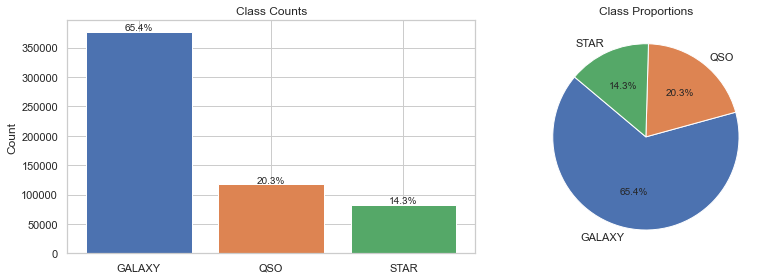

In [3]:
vc = df["class"].value_counts().reindex(CLASS_ORDER)
pct = (vc / len(df) * 100).round(2)
class_summary = pd.DataFrame({"count": vc, "pct": pct})
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(vc.index, vc.values, color=[CLASS_COLORS[c] for c in vc.index])
for i, (v, p) in enumerate(zip(vc.values, pct.values)):
    axes[0].text(i, v + 2000, f"{p:.1f}%", ha="center", fontsize=10)
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=[CLASS_COLORS[c] for c in vc.index], startangle=140)
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

## 3. Categorical Features vs. Class


── spectral_type (row % within each category) ──


class,GALAXY,QSO,STAR
spectral_type,,,
A/F,19.8,50.4,29.8
G/K,56.8,19.3,24.0
M,95.0,1.3,3.8
O/B,8.3,71.1,20.6


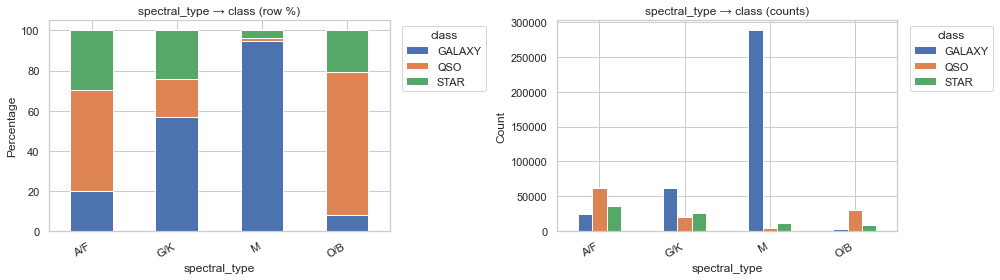


── galaxy_population (row % within each category) ──


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,34.5,42.0,23.5
Red_Sequence,90.3,2.8,6.9


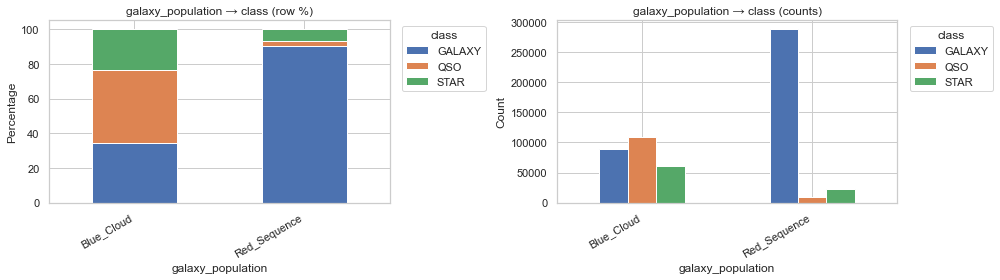

In [4]:
cat_features = ["spectral_type", "galaxy_population"]

for feat in cat_features:
    ct = pd.crosstab(df[feat], df["class"], normalize="index").reindex(columns=CLASS_ORDER) * 100
    print(f"\n── {feat} (row % within each category) ──")
    display(ct.round(1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Stacked bar — row pct
    ct.plot(kind="bar", stacked=True, ax=axes[0],
            color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor="white")
    axes[0].set_title(f"{feat} → class (row %)")
    axes[0].set_ylabel("Percentage")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")
    axes[0].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

    # Absolute counts grouped
    ct_abs = pd.crosstab(df[feat], df["class"]).reindex(columns=CLASS_ORDER)
    ct_abs.plot(kind="bar", ax=axes[1],
                color=[CLASS_COLORS[c] for c in CLASS_ORDER], edgecolor="white")
    axes[1].set_title(f"{feat} → class (counts)")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
    axes[1].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

## 4. Numeric Feature Distributions by Class

In [5]:
# Per-class statistics table
num_cols = ["alpha", "delta", "u", "g", "r", "i", "z", "redshift"]
grp_stats = df.groupby("class")[num_cols].agg(["mean", "median", "std"]).round(4)
display(grp_stats)

alpha                        delta                          u  \
            mean    median       std     mean   median      std     mean   
class                                                                      
GALAXY  178.5572  191.9881   91.8308  21.0334  20.0148  18.4810  22.9892   
QSO     189.6660  186.1515  103.4713  25.8118  29.2789  19.5830  21.7248   
STAR    184.1788  188.0687  104.2313  19.8587  19.5670  19.2641  20.9604   

                               g  ...       r        i                   \
         median     std     mean  ...     std     mean   median     std   
class                             ...                                     
GALAXY  23.1388  1.9968  21.2701  ...  1.6900  19.0682  19.3991  1.4997   
QSO     21.7008  1.1507  21.1603  ...  0.7949  20.7673  20.8690  0.7923   
STAR    20.7582  2.0167  19.5910  ...  1.7089  18.8306  18.8160  1.6739   

              z                  redshift                  
           mean   median     std     mean  median     std  
class                                                      
GALAXY  18.6299  18.9284  1.4426   0.5090  0.4820  0.3091  
QSO     20.6021  20.6977  0.7867   1.8756  1.7989  1.0697  
STAR    18.7072  18.6959  1.6771   0.0681  0.0565  0.0645  

[3 rows x 24 columns]

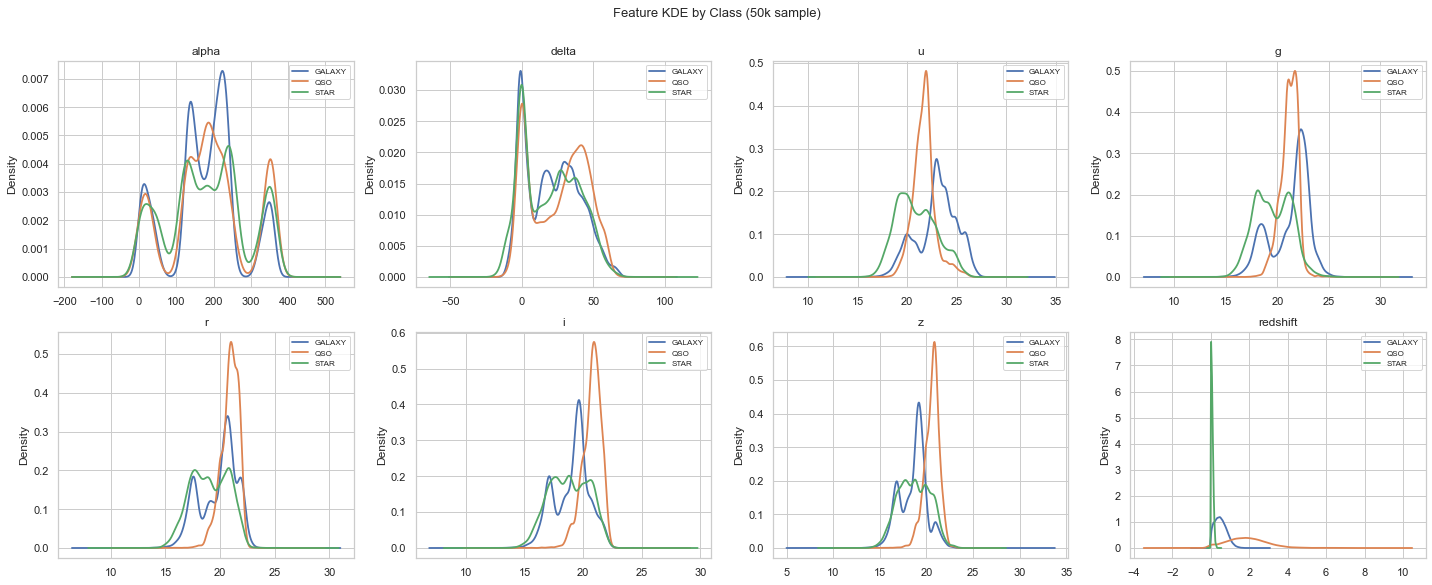

In [6]:
# KDE + rug plots for each numeric feature
sample = df.sample(n=min(50_000, len(df)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for cls in CLASS_ORDER:
        subset = sample.loc[sample["class"] == cls, col]
        subset.plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=1.8)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Feature KDE by Class (50k sample)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

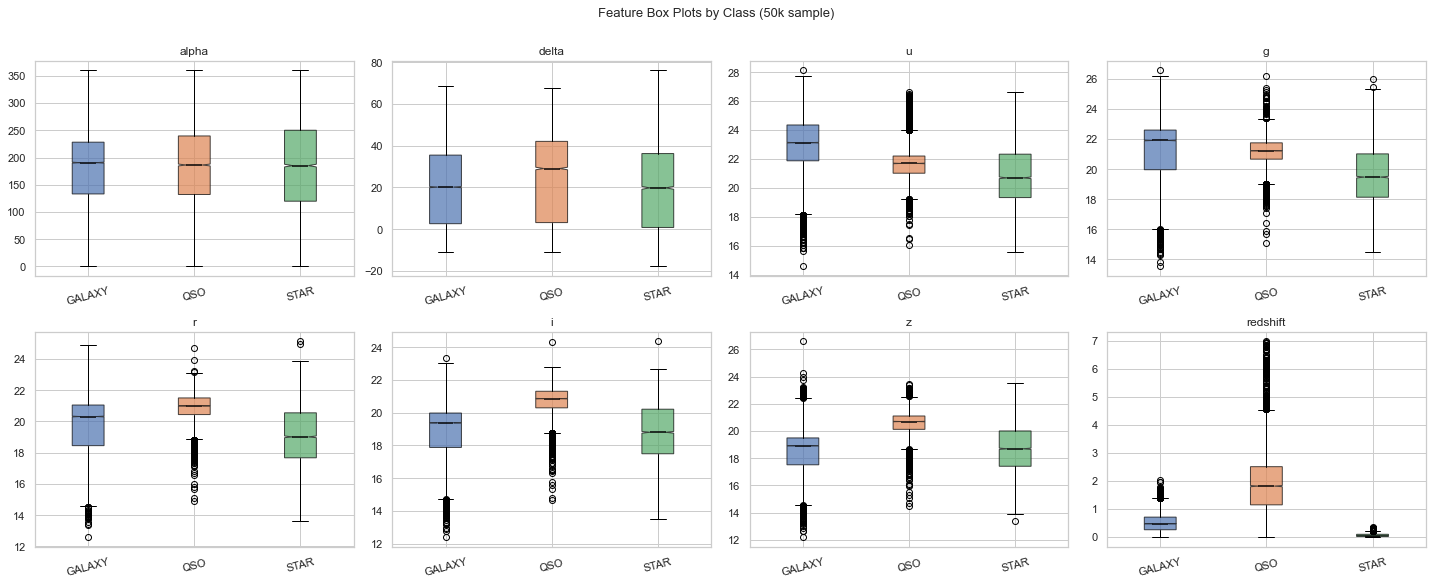

In [7]:
# Box plots — same layout
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = [sample.loc[sample["class"] == cls, col].values for cls in CLASS_ORDER]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, cls in zip(bp["boxes"], CLASS_ORDER):
        patch.set_facecolor(CLASS_COLORS[cls])
        patch.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(CLASS_ORDER, rotation=15)
    ax.set_title(col)

plt.suptitle("Feature Box Plots by Class (50k sample)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Photometric Color Indices
Color indices (differences between adjacent bands) are a primary signal in astronomical classification.

u_g                     g_r                     r_i          \
          mean  median     std    mean  median     std    mean  median   
class                                                                    
GALAXY  1.7190  1.6938  1.1628  1.4096  1.4809  0.5775  0.7923  0.7948   
QSO     0.5644  0.3832  0.8109  0.2415  0.2136  0.3969  0.1515  0.1412   
STAR    1.3694  1.2207  0.7457  0.5152  0.4531  0.4869  0.2453  0.1930   

                   i_z                  
           std    mean  median     std  
class                                   
GALAXY  0.4156  0.4383  0.4368  0.3526  
QSO     0.3451  0.1652  0.1680  0.3912  
STAR    0.4335  0.1234  0.1190  0.4182

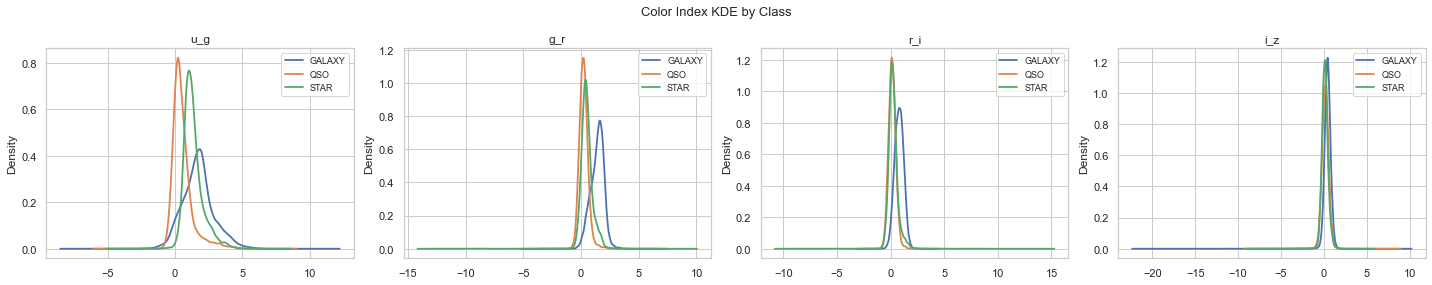

In [8]:
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]
color_cols = ["u_g", "g_r", "r_i", "i_z"]

sample = df.sample(n=min(50_000, len(df)), random_state=42)

# Color index stats by class
display(df.groupby("class")[color_cols].agg(["mean", "median", "std"]).round(4))

# KDE plots
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, color_cols):
    for cls in CLASS_ORDER:
        subset = sample.loc[sample["class"] == cls, col]
        subset.plot.kde(ax=ax, label=cls, color=CLASS_COLORS[cls], linewidth=1.8)
    ax.set_title(col)
    ax.legend(fontsize=9)
plt.suptitle("Color Index KDE by Class", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Redshift Deep Dive

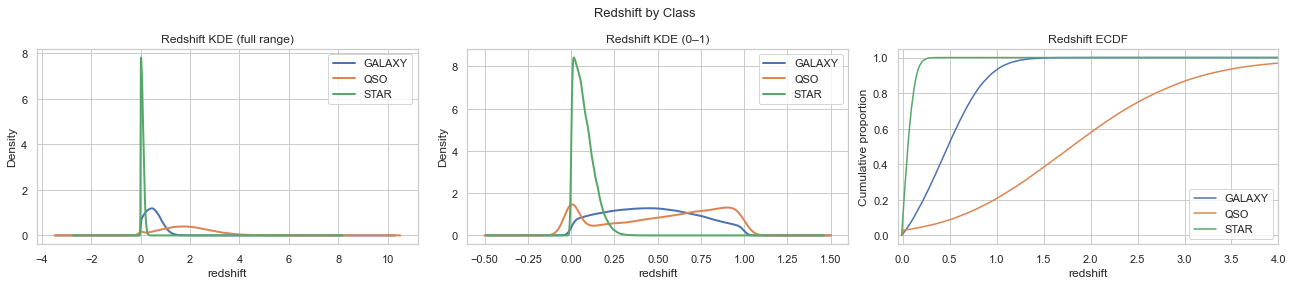

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Full KDE
for cls in CLASS_ORDER:
    df.loc[df["class"] == cls, "redshift"].plot.kde(
        ax=axes[0], label=cls, color=CLASS_COLORS[cls], linewidth=2)
axes[0].set_title("Redshift KDE (full range)")
axes[0].set_xlabel("redshift")
axes[0].legend()

# Clipped view (zoom into 0–1)
for cls in CLASS_ORDER:
    subset = df.loc[(df["class"] == cls) & (df["redshift"].between(0, 1)), "redshift"]
    subset.plot.kde(ax=axes[1], label=cls, color=CLASS_COLORS[cls], linewidth=2)
axes[1].set_title("Redshift KDE (0–1)")
axes[1].set_xlabel("redshift")
axes[1].legend()

# ECDF
for cls in CLASS_ORDER:
    vals = np.sort(df.loc[df["class"] == cls, "redshift"].values)
    ecdf = np.arange(1, len(vals) + 1) / len(vals)
    axes[2].plot(vals, ecdf, label=cls, color=CLASS_COLORS[cls], linewidth=1.5)
axes[2].set_title("Redshift ECDF")
axes[2].set_xlabel("redshift")
axes[2].set_ylabel("Cumulative proportion")
axes[2].set_xlim(-0.05, 4)
axes[2].legend()

plt.suptitle("Redshift by Class", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Color–Color Diagrams
Classic diagnostic plots in astronomy: `u-g` vs `g-r`, and `r-i` vs `g-r`.

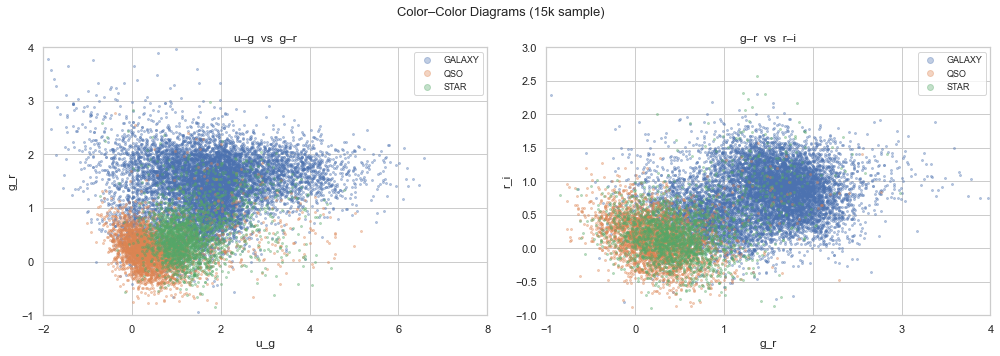

In [10]:
tiny = df.sample(n=min(15_000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [("u_g", "g_r"), ("g_r", "r_i")]
titles = ["u–g  vs  g–r", "g–r  vs  r–i"]
clip = {"u_g": (-2, 8), "g_r": (-1, 4), "r_i": (-1, 3)}

for ax, (xcol, ycol), title in zip(axes, pairs, titles):
    for cls in CLASS_ORDER:
        sub = tiny[tiny["class"] == cls]
        ax.scatter(sub[xcol], sub[ycol], s=4, alpha=0.35,
                   color=CLASS_COLORS[cls], label=cls)
    ax.set_xlim(*clip[xcol])
    ax.set_ylim(*clip[ycol])
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle("Color–Color Diagrams (15k sample)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Redshift vs. Color Index Scatter

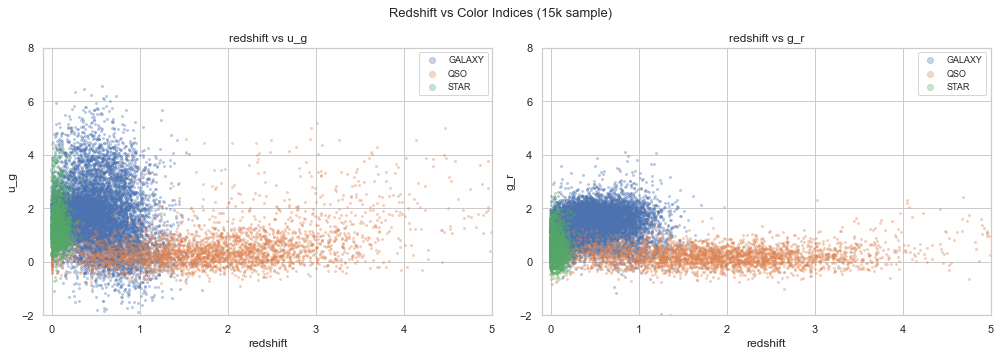

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ycol in zip(axes, ["u_g", "g_r"]):
    for cls in CLASS_ORDER:
        sub = tiny[tiny["class"] == cls]
        ax.scatter(sub["redshift"], sub[ycol], s=4, alpha=0.3,
                   color=CLASS_COLORS[cls], label=cls)
    ax.set_xlabel("redshift")
    ax.set_ylabel(ycol)
    ax.set_xlim(-0.1, 5)
    ax.set_ylim(-2, 8)
    ax.set_title(f"redshift vs {ycol}")
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle("Redshift vs Color Indices (15k sample)", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Sky Position (RA / Dec)

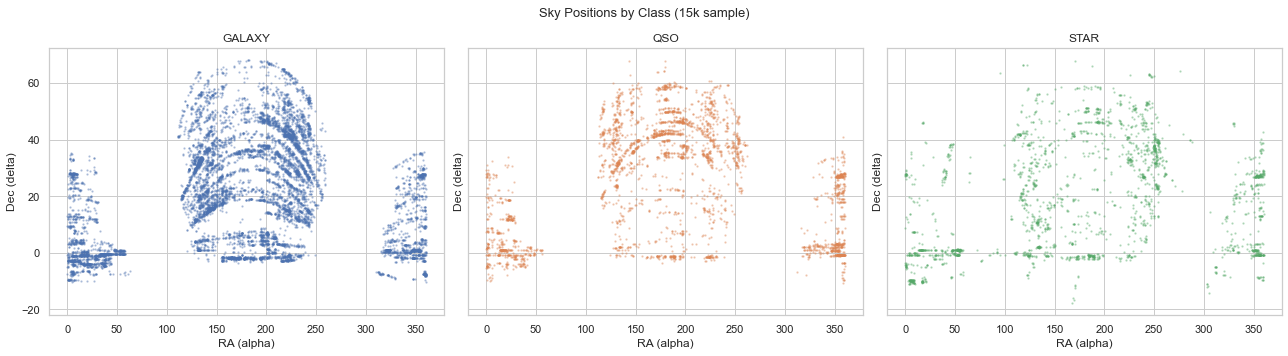

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cls in zip(axes, CLASS_ORDER):
    sub = tiny[tiny["class"] == cls]
    ax.scatter(sub["alpha"], sub["delta"], s=2, alpha=0.3, color=CLASS_COLORS[cls])
    ax.set_title(cls)
    ax.set_xlabel("RA (alpha)")
    ax.set_ylabel("Dec (delta)")

plt.suptitle("Sky Positions by Class (15k sample)", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Correlation Heatmaps by Class

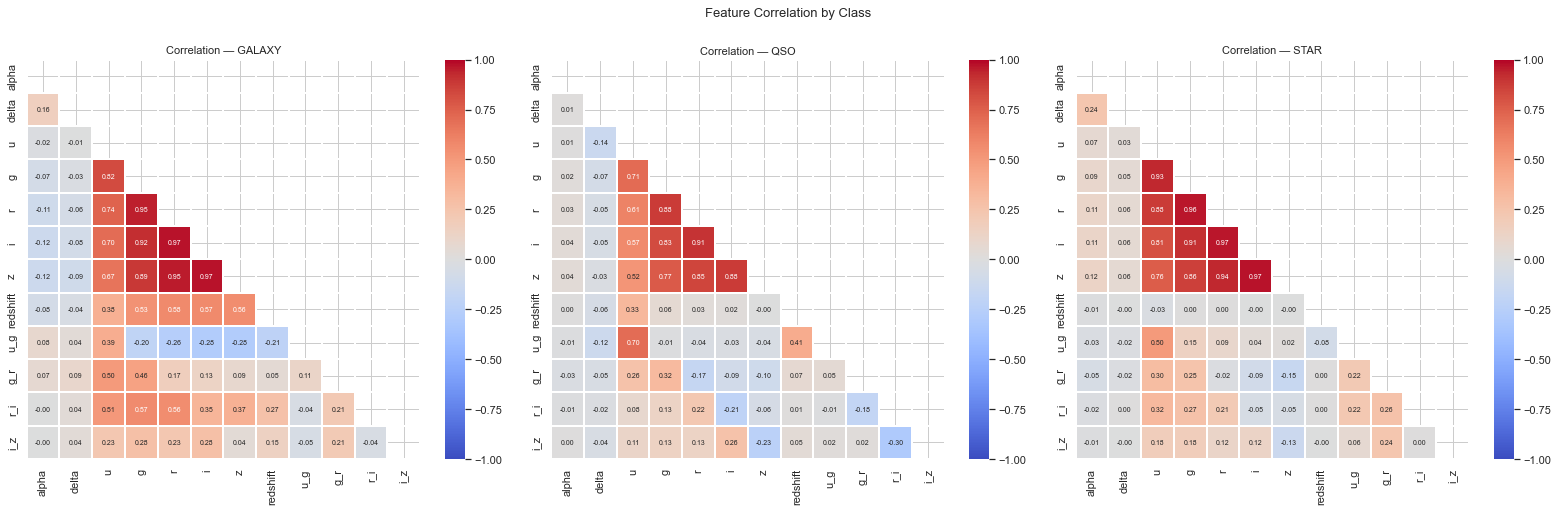

In [13]:
all_num = num_cols + color_cols
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, cls in zip(axes, CLASS_ORDER):
    corr = df[df["class"] == cls][all_num].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
                cmap="coolwarm", vmin=-1, vmax=1,
                annot_kws={"size": 7}, linewidths=0.3)
    ax.set_title(f"Correlation — {cls}", fontsize=11)

plt.suptitle("Feature Correlation by Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. Feature Separability — ANOVA F-Score & Effect Size

,feature,F_score,p_value
0,redshift,352900.4,0.00e+00
1,g_r,262410.0,0.00e+00
2,r_i,145631.8,0.00e+00
3,z,94881.3,0.00e+00
4,i,71806.6,0.00e+00
5,u_g,54503.0,0.00e+00
6,u,51307.8,0.00e+00
7,i_z,40421.4,0.00e+00
8,r,36471.2,0.00e+00
9,g,33737.8,0.00e+00


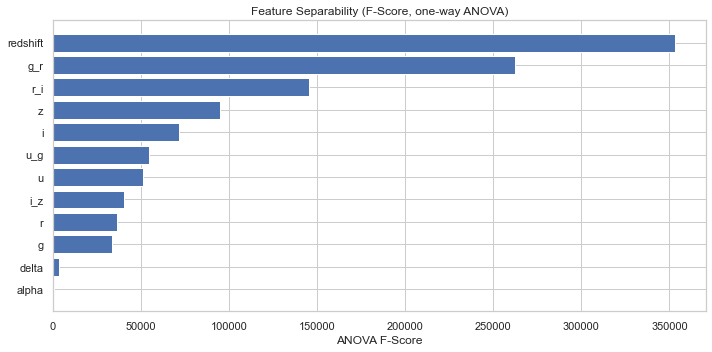

In [14]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

feats = num_cols + color_cols
le = LabelEncoder()
y = le.fit_transform(df["class"])
X = df[feats].values

f_scores, p_values = f_classif(X, y)

sep_df = pd.DataFrame({
    "feature": feats,
    "F_score": f_scores,
    "p_value": p_values,
}).sort_values("F_score", ascending=False).reset_index(drop=True)
display(sep_df.style.background_gradient(subset=["F_score"], cmap="YlOrRd").format({"F_score": "{:.1f}", "p_value": "{:.2e}"}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(sep_df["feature"][::-1], sep_df["F_score"][::-1], color="#4C72B0")
ax.set_xlabel("ANOVA F-Score")
ax.set_title("Feature Separability (F-Score, one-way ANOVA)")
plt.tight_layout()
plt.show()

## 12. Key Takeaways

In [15]:
print("""
Key signals identified for multi-class classification (GALAXY / QSO / STAR):

1. REDSHIFT is the single strongest discriminator:
   - STAR: tightly clustered near 0
   - GALAXY: moderate range ~0–1
   - QSO: wide spread, reaching >5

2. COLOR INDICES (u-g, g-r, r-i, i-z) are highly separating:
   - Stars occupy a narrow stellar locus
   - QSOs scatter far from the locus (especially u-g)
   - Color-color diagrams cleanly separate classes

3. SPECTRAL TYPE is strongly predictive:
   - O/B → mostly QSO
   - M → mostly GALAXY / STAR
   - A/F, G/K → mixed but with clear modal patterns

4. GALAXY POPULATION separates GALAXY from others:
   - Red_Sequence / Blue_Cloud labels are mostly on GALAXYs

5. PHOTOMETRIC BANDS (u, g, r, i, z):
   - QSOs tend to be brighter (lower magnitude) in u
   - Stars have narrow, sharp magnitude peaks

6. SKY POSITION (alpha/delta): largely uniform across classes — likely low signal.

Recommended feature engineering:
   - Color indices: u-g, g-r, r-i, i-z  (already computed)
   - log(1 + redshift)
   - One-hot or ordinal encoding of spectral_type, galaxy_population
""")



Key signals identified for multi-class classification (GALAXY / QSO / STAR):

1. REDSHIFT is the single strongest discriminator:
   - STAR: tightly clustered near 0
   - GALAXY: moderate range ~0–1
   - QSO: wide spread, reaching >5

2. COLOR INDICES (u-g, g-r, r-i, i-z) are highly separating:
   - Stars occupy a narrow stellar locus
   - QSOs scatter far from the locus (especially u-g)
   - Color-color diagrams cleanly separate classes

3. SPECTRAL TYPE is strongly predictive:
   - O/B → mostly QSO
   - M → mostly GALAXY / STAR
   - A/F, G/K → mixed but with clear modal patterns

4. GALAXY POPULATION separates GALAXY from others:
   - Red_Sequence / Blue_Cloud labels are mostly on GALAXYs

5. PHOTOMETRIC BANDS (u, g, r, i, z):
   - QSOs tend to be brighter (lower magnitude) in u
   - Stars have narrow, sharp magnitude peaks

6. SKY POSITION (alpha/delta): largely uniform across classes — likely low signal.

Recommended feature engineering:
   - Color indices: u-g, g-r, r-i, i-z  (alr